# Ideal Kerr Cat Floquet analysis

In this initial demo we perform the Floquet analysis on a transmon with a readout frequency above the qubit frequency, mapping the probability of ionization as a function of drive strength and drive frequency. We then compare these simulations to Blais-style branch crossing plots, which identify the states the qubit states leak to.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
import scqubits as scq
from cycler import cycler

import floquet as ft


color_cycler = cycler(plt.rcParams["axes.prop_cycle"])
ls_cycler = cycler(ls=["-", "--", "-.", ":"])
alpha_cycler = cycler(alpha=[1.0, 0.6, 0.2])
color_ls_alpha_cycler = alpha_cycler * ls_cycler * color_cycler

## Kerr Cat

In [2]:
filepath = ft.generate_file_path("h5py", "transmon_floquet", "out")

# Transmon parameters
num_states = 30

qubit_params = {"omega_r": 6.0, "K": 0.5e-3, "delta_const": 0.0, "eps_2_over_Omega_d": 2.5e-3}
state_indices = [0, 1]  # get data for ground and first excited states


# Express operators in eigenbasis of transmon
def get_H0_H1(qubit_params) -> tuple[qt.Qobj, qt.Qobj]:
    a = qt.destroy(num_states)
    adag = a.dag()
    eye = qt.qeye(num_states)

    # Static Hamiltonian (without harmonic part)
    H0 =  qubit_params['omega_r'] * adag * a
    H0 -= qubit_params['K'] * adag * adag * a * a
    H0 += qubit_params['delta_const'] * adag * a

    # Charge drive; time in 1/GHz = ns
    H1 = (adag * adag + a * a) * qubit_params['eps_2_over_Omega_d']
    
    # Full t-dep Hamiltonian
    return 2.0 * np.pi * H0, 2.0 * np.pi * H1

H0, H1 = get_H0_H1(qubit_params)

# Drive parameters (freq and amp to scan over)
omega_d_values = 2.0 * np.pi * np.linspace(11.5, 12.5, 60)
drive_amplitudes = np.tile(np.linspace(0.0, 10.0, 101)[:, None], (1, len(omega_d_values)))

# initialize the model to pass to FloquetAnalysis
model = ft.Model(
    H0, H1, omega_d_values=omega_d_values, drive_amplitudes=drive_amplitudes
)

options = ft.Options(
    fit_range_fraction=0.5,  # split the fit into segments based on this fraction
    floquet_sampling_time_fraction=0.0,  # fraction of the period to compute the Floquet modes  # noqa E501
    fit_cutoff=4,  # polynomial cutoff
    overlap_cutoff=0.8,  # cutoff for excluding from the fit
    nsteps=30_000,  # qutip integration parameter
    num_cpus=6,  # number of cpus to use to compute Floquet modes in parallel
    save_floquet_modes=True,  # whether or not to save floquet modes themselves
)

In [3]:
floquet_analysis = ft.FloquetAnalysis(
    model, state_indices=state_indices, options=options
)
data_vals = floquet_analysis.run(filepath=filepath)

Running floquet simulation with parameters: 
model: H0: Quantum object: dims=[[30], [30]], shape=(30, 30), type='oper', dtype=Dia, isherm=True
Qobj data =
[[   0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.        ]
 [   0.           37.69911184    0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.
     0.            0.            0.            0.            0.        ]
 [   0.            0.           75.3919405     0.          

calculating for amp_range_idx=1
finished in 0.5457418481508891 minutes


## Branch analysis

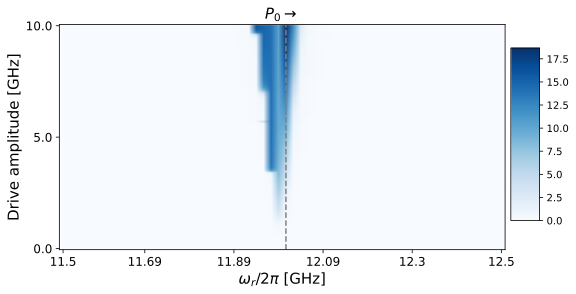

In [4]:
state_idx = 0
omega_d_idx = 30

plot_data = data_vals["avg_excitation"][:, :, state_idx].T

fig, ax = plt.subplots(figsize=(8, 8))
xticks = omega_d_values / (2.0 * np.pi)
yticks = drive_amplitudes[:,0]
num_x_pts = len(xticks)
num_y_pts = len(yticks)
im = plt.imshow(
    plot_data, origin="lower", cmap="Blues", aspect=0.3, interpolation="none"
)
plt.axvline(omega_d_idx, color="grey", ls="--")
ax.set_title(f"$P_{state_idx}$" + r"$\rightarrow$", fontsize=15)
xticklabel_locations = np.linspace(0, num_x_pts - 1, 6, dtype=int)
ax.set_xticks(xticklabel_locations)
ax.set_xticklabels(
    np.array(np.around(xticks[xticklabel_locations], decimals=2), dtype=str),
    fontsize=12,
)
yticklabel_locations = np.linspace(0, num_y_pts - 1, 3, dtype=int)
ax.set_yticks(yticklabel_locations)
ax.set_yticklabels(
    np.array(np.around(yticks[yticklabel_locations], decimals=2), dtype=str),
    fontsize=12,
)
ax.set_ylabel(r"Drive amplitude [GHz]", fontsize=15)
ax.set_xlabel(r"$\omega_r/2\pi$ [GHz]", fontsize=15)
cax = plt.axes([0.91, 0.35, 0.05, 0.3])
cbar = plt.colorbar(im, cax=cax)
plt.show()

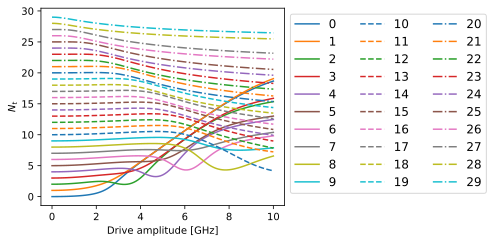

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for curve_idx, sty in zip(
    range(floquet_analysis.hilbert_dim), color_ls_alpha_cycler, strict=False
):
    plt.plot(
        drive_amplitudes[:,0],
        data_vals["avg_excitation"][omega_d_idx, :, curve_idx],
        label=curve_idx,
        **sty,
    )
ax.set_ylabel(r"$N_{t}$")
ax.set_xlabel("Drive amplitude [GHz]")
ax.legend(fontsize=12, ncol=3, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig("branch_analysis.pdf")
plt.show()

## Plot the probability of nonlinear transitions

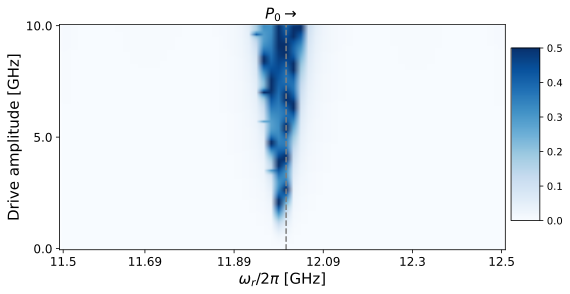

In [6]:
state_idx = 0
omega_d_idx = 30

plot_data = np.clip(
    1 - data_vals["displaced_state_overlaps"][:, :, state_idx].T ** 2, 0.0, 0.5
)

fig, ax = plt.subplots(figsize=(8, 8))
xticks = omega_d_values / (2.0 * np.pi)
yticks = drive_amplitudes[:,0]
num_x_pts = len(xticks)
num_y_pts = len(yticks)
im = plt.imshow(
    plot_data, origin="lower", cmap="Blues", aspect=0.3, interpolation="none"
)
plt.axvline(omega_d_idx, color="grey", ls="--")
ax.set_title(f"$P_{state_idx}$" + r"$\rightarrow$", fontsize=15)
xticklabel_locations = np.linspace(0, num_x_pts - 1, 6, dtype=int)
ax.set_xticks(xticklabel_locations)
ax.set_xticklabels(
    np.array(np.around(xticks[xticklabel_locations], decimals=2), dtype=str),
    fontsize=12,
)
yticklabel_locations = np.linspace(0, num_y_pts - 1, 3, dtype=int)
ax.set_yticks(yticklabel_locations)
ax.set_yticklabels(
    np.array(np.around(yticks[yticklabel_locations], decimals=2), dtype=str),
    fontsize=12,
)
ax.set_ylabel(r"Drive amplitude [GHz]", fontsize=15)
ax.set_xlabel(r"$\omega_r/2\pi$ [GHz]", fontsize=15)
cax = plt.axes([0.91, 0.35, 0.05, 0.3])
cbar = plt.colorbar(im, cax=cax)
plt.show()

## Exploring the fit

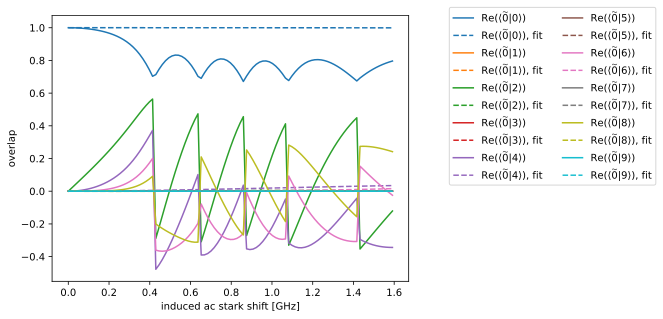

In [7]:
omega_d = omega_d_values[omega_d_idx]
displaced_state = ft.DisplacedState(
    hilbert_dim=floquet_analysis.hilbert_dim,
    model=model,
    state_indices=state_indices,
    options=options,
)

fig, ax = plt.subplots()
for comp_idx, color in zip(range(10), color_cycler, strict=False):
    ideal_state_component = displaced_state.displaced_state(
        coefficients=data_vals["fit_data"], 
        omega_d_idxs = [omega_d_idx, omega_d_idx+1]
    )[0, :, state_idx, comp_idx]

    # Components of the true Floquet mode
    plt.plot(
        drive_amplitudes[:,0] / 2 / np.pi,
        np.real(data_vals["floquet_modes"][omega_d_idx, :, state_idx, comp_idx]),
        label=rf"Re($\langle\widetilde{state_idx}|{comp_idx} \rangle$)",
        color=color["color"],
    )
    # Components of the fitted state
    plt.plot(
        drive_amplitudes[:,0] / 2 / np.pi,
        np.real(np.squeeze(ideal_state_component)),
        ls="--",
        label=rf"Re($\langle\widetilde{state_idx}|{comp_idx} \rangle$), fit",
        color=color["color"],
    )
ax.legend(ncol=2, bbox_to_anchor=(1.1, 1.05))
ax.set_xlabel("induced ac stark shift [GHz]")
ax.set_ylabel("overlap")
plt.show()

In [8]:
1

1